# Analisi Qualita' Dati RTP x Supporto GO-LIVE (Tassonomie,Date Scadenza)

Questo notebook esegue una serie di passaggi per identificare la qualità di alcuni campi delle posizioni debitorie GPD.

# Perimetro Dati in analisi
1) Posizioni Debitorie su GPD e ACA (no paCreatePosition)
2) Posizioni Debitore "VALID"
3) Periodo temporale 01/01/2026 -> oggi

In [10]:
import cml.data_v1 as cmldata

In [11]:
CONNECTION_NAME = "dl-analysis-impala-vw"
conn = cmldata.get_connection(CONNECTION_NAME)

In [12]:
## Sample Usage to get pandas data frame
QUERY = """
select t.after.category as category, po.after.description as description, pp.after.id as id, pp.after.iupd as iupd, po.after.due_date as due_date, pp.after.company_name as company_name
from pagopa.silver_gpd_payment_position pp
INNER JOIN pagopa.silver_gpd_payment_option po ON pp.after.id = po.after.payment_position_id
INNER JOIN pagopa.silver_gpd_transfer t ON t.after.payment_option_id = po.after.id
WHERE 
pp.after.inserted_date is not null
and pp.after.inserted_date BETWEEN unix_timestamp('2026-01-01 00:00:00')*1000000 AND unix_timestamp('2026-03-01 00:00:00')*1000000  
and pp.after.status in ('VALID')
and pp.after.iupd not like 'ACA_%' and pp.after.service_type in ('GPD','ACA')
"""

dataframe = conn.get_pandas_dataframe(QUERY)
# Closing the connection
conn.close()

In [13]:
import pandas as pd
import re
import requests
import io
import csv

# --- 1. CARICAMENTO TASSONOMIA (METODO ULTRA-ROBUSTO) ---
url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url_taxonomy, headers=headers)
    response.raise_for_status()
    
    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    header = [h.replace('"', '').strip() for h in header]
    col_idx = header.index(col_ref)
    
    valid_codes_list = []
    scarti_csv = [] 

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append({
                    'riga_csv': i,
                    'valore_trovato': raw_code,
                    'note': 'Formato non valido'
                })
        else:
            scarti_csv.append({
                'riga_csv': i,
                'valore_trovato': 'N/D',
                'note': 'Colonna mancante'
            })

    valid_codes_set = set(valid_codes_list)
    
    print(f"--- ANALISI FILE CSV (via URL) ---")
    print(f"Record totali processati:     {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci (validi):      {len(valid_codes_set)}")

except Exception as e:
    print(f"❌ Errore nel caricamento della tassonomia: {e}")
    valid_codes_set = set()


# --- 2. VALIDAZIONE SUL TUO DATAFRAME ---

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

if 'category' in dataframe.columns:

    # Normalizzazione
    dataframe['category_clean'] = (
        dataframe['category']
        .astype(str)
        .str.replace('"', '')
        .str.strip()
    )

    # A. Validazione Sintattica Principale
    dataframe['is_syntax_correct'] = dataframe['category_clean'].str.match(
        taxonomic_regex, na=False
    )

    # B. Validazione Sintattica Alternativa (7 cifre + suffisso)
    dataframe['is_secondary_syntax'] = dataframe['category_clean'].str.match(
        secondary_regex, na=False
    )

    # C. Validazione Semantica
    dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)

    # D. Prefissi specifici (6/7/8)
    dataframe['is_specific_prefix'] = (
        dataframe['is_semantically_correct'] &
        dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
    )

    # --- 3. REPORT GENERALE ---
    total_records = len(dataframe)
    syntax_ok = dataframe['is_syntax_correct'].sum()
    syntax_ko = total_records - syntax_ok

    semantic_ok = dataframe['is_semantically_correct'].sum()
    specific_prefix_ok = dataframe['is_specific_prefix'].sum()

    # --- SOTTO-ANALISI DEI SINTASSI ERRATI ---
    syntax_ko_df = dataframe[~dataframe['is_syntax_correct']]
    secondary_ok = syntax_ko_df['is_secondary_syntax'].sum()
    secondary_ko = syntax_ko - secondary_ok

    print("\n" + "="*95)
    print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
    print("="*95)
    print(f"Totale record analizzati:      {total_records}")
    print(f"1) Rispettano la sintassi:     {syntax_ok} ✅")
    print(f"2) NON rispettano la sintassi: {syntax_ko} ❌")
    print(f"   2.1) Rispettano sintassi alternativa (7 cifre + suffisso): {secondary_ok}")
    print(f"   2.2) NON rispettano neanche la sintassi alternativa:       {secondary_ko}")
    
    if syntax_ko > 0:
        print(f"\n% errori recuperabili con sola aggiunta prefisso: {secondary_ok / syntax_ko:.2%}")

    print(f"\n3) Semanticamente corretti:    {semantic_ok} 🏛️")
    print(f"4) Prefissi Specifici (6/7/8): {specific_prefix_ok} 🏷️")
    print("-" * 95)


    # --- 4. ESEMPI REALI ---
    print("\nDETTAGLIO ESEMPI REALI:")
    casistiche = [
        ("✅ Sintassi OK", dataframe[dataframe['is_syntax_correct']]),
        ("❌ Sintassi Errata", dataframe[~dataframe['is_syntax_correct']]),
        ("🔄 Sintassi Alternativa", dataframe[dataframe['is_secondary_syntax']]),
        ("🏛️ Semantica OK", dataframe[dataframe['is_semantically_correct']]),
        ("🏷️ Prefisso 6/7/8", dataframe[dataframe['is_specific_prefix']])
    ]

    for label, df_sub in casistiche:
        if not df_sub.empty:
            row = df_sub.iloc[0]
            print(f"{label:25} -> Codice: {row['category']:15} | ID: {row['id']:15} | IUPD: {row['iupd']}")
        else:
            print(f"{label:25} -> Nessun record trovato")


    # --- 5. RAGGRUPPAMENTO PER COMPANY_NAME ---
    if 'company_name' in dataframe.columns:
        stats_company = dataframe.groupby('company_name').agg(
            Sintassi_OK=('is_syntax_correct', 'sum'),
            Sintassi_Alt=('is_secondary_syntax', 'sum'),
            Semantica_OK=('is_semantically_correct', 'sum'),
            Prefissi_678=('is_specific_prefix', 'sum'),
            Totale_Record=('category', 'count')
        )

        stats_company['Sintassi_KO'] = stats_company['Totale_Record'] - stats_company['Sintassi_OK']

        stats_company = stats_company[
            ['Sintassi_OK', 'Sintassi_KO', 'Sintassi_Alt',
             'Semantica_OK', 'Prefissi_678', 'Totale_Record']
        ]

        top_10 = stats_company.sort_values(
            by='Totale_Record',
            ascending=False
        ).head(10)

        print("\n" + "="*95)
        print("🏢 STATISTICHE PER COMPANY (Top 10 per volume)")
        print("="*95)
        display(top_10)

        # --- FOCUS DETTAGLIATO PER COMPANY ---
        for company in top_10.index:
            print(f"\n🔍 FOCUS AZIENDA: {company}")
            df_comp = dataframe[dataframe['company_name'] == company]

            casistiche_comp = [
                ("✅ Sintassi OK", df_comp[df_comp['is_syntax_correct']]),
                ("❌ Sintassi Errata", df_comp[~df_comp['is_syntax_correct']]),
                ("🔄 Regex Alternativa OK", df_comp[df_comp['is_secondary_syntax']]),
                ("🚫 Regex Alternativa KO", df_comp[~df_comp['is_secondary_syntax']]),
                ("🏛️ Semantica OK", df_comp[df_comp['is_semantically_correct']]),
                ("🏷️ Prefisso 6/7/8", df_comp[df_comp['is_specific_prefix']])
            ]

            for label, df_sub in casistiche_comp:
                if not df_sub.empty:
                    row = df_sub.iloc[0]
                    print(f"   {label:25} -> Codice: {row['category']:15} | ID: {row['id']:15} | IUPD: {row['iupd']}")
                else:
                    print(f"   {label:25} -> Nessun record trovato")

            print("-" * 80)


    else:
        print("\n⚠️ Colonna 'company_name' non trovata.")

else:
    print("❌ Errore: Colonna 'category' non trovata.")

--- ANALISI FILE CSV (via URL) ---
Record totali processati:     3024
Codici univoci (validi):      3016

📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      5179686
1) Rispettano la sintassi:     1236345 ✅
2) NON rispettano la sintassi: 3943341 ❌
   2.1) Rispettano sintassi alternativa (7 cifre + suffisso): 1708107
   2.2) NON rispettano neanche la sintassi alternativa:       2235234

% errori recuperabili con sola aggiunta prefisso: 43.32%

3) Semanticamente corretti:    1209389 🏛️
4) Prefissi Specifici (6/7/8): 0 🏷️
-----------------------------------------------------------------------------------------------

DETTAGLIO ESEMPI REALI:
✅ Sintassi OK             -> Codice: 9/0102100SA/    | ID:       261272612 | IUPD: 00251080230APPICA00141_187907
❌ Sintassi Errata         -> Codice: 0102100SA       | ID:       259656412 | IUPD: 00215150236-fec3a1cb-5cd4-48e7-8a39-a55204aa6b2a
🔄 Sintassi Alternativa    -> Codice: 0102100SA       | ID:       259656412 | IUPD: 00

,Sintassi_OK,Sintassi_KO,Sintassi_Alt,Semantica_OK,Prefissi_678,Totale_Record
company_name,,,,,,
Regione Campania,22,980399,0,22,0,980421
C.C.I.A.A. DI ROMA,0,316195,0,0,0,316195
Regione del Veneto,0,205427,205427,0,0,205427
AREA S.R.L.,99905,0,0,99682,0,99905
COMUNE DI FIRENZE,88094,0,0,88094,0,88094
C.C.I.A.A. DI SALERNO,0,77207,0,0,0,77207
ACQUEDOTTO PUGLIESE S.P.A.,0,73416,0,0,0,73416
Municipia s.p.a,0,68763,0,0,0,68763
Autostrade per l Italia S.p.A.,60110,0,0,60110,0,60110



🔍 FOCUS AZIENDA: Regione Campania
   ✅ Sintassi OK             -> Codice: 9/0301118SP/    | ID:       252637915 | IUPD: b11ff9fc-97604932a1bb-19b8ea49907
   ❌ Sintassi Errata         -> Codice: 9/0301107TS/1313 | ID:       252636896 | IUPD: b11ff9fc-e0c646bba493-19b8ea3f21d
   🔄 Regex Alternativa OK    -> Nessun record trovato
   🚫 Regex Alternativa KO    -> Codice: 9/0301107TS/1313 | ID:       252636896 | IUPD: b11ff9fc-e0c646bba493-19b8ea3f21d
   🏛️ Semantica OK           -> Codice: 9/0301118SP/    | ID:       252637915 | IUPD: b11ff9fc-97604932a1bb-19b8ea49907
   🏷️ Prefisso 6/7/8         -> Nessun record trovato
--------------------------------------------------------------------------------

🔍 FOCUS AZIENDA: C.C.I.A.A. DI ROMA
   ✅ Sintassi OK             -> Nessun record trovato
   ❌ Sintassi Errata         -> Codice: 9/97000000085695126 | ID:       261746360 | IUPD: 8009979058897000000085695126
   🔄 Regex Alternativa OK    -> Nessun record trovato
   🚫 Regex Alternativa KO    -

## Analisi lunghezza causali

> 1 e <= 30 caratteri: 2907088 record (56.12%)
> 30 e <= 50 caratteri: 1523812 record (29.42%)
> 50 e <= 70 caratteri: 410771 record (7.93%)
> 70 e <= 100 caratteri: 220196 record (4.25%)
> 100 e <= 140 caratteri: 10177 record (0.20%)
> 140 caratteri: 0 record (0.00%)


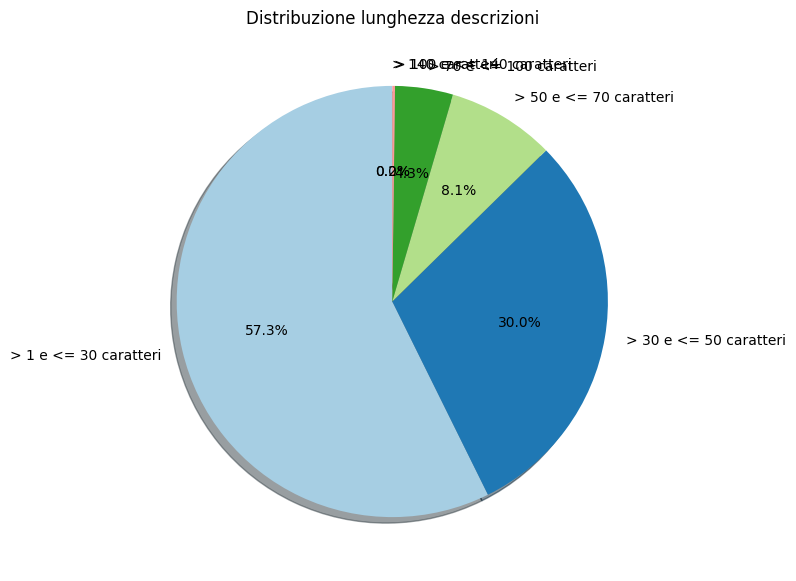

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_description_length(df):
    
    # Definizione delle categorie di lunghezza
    bins = [(1, 30), (31, 50), (51, 70), (71, 100), (101, 140), (141, float('inf'))]
    labels = ["> 1 e <= 30 caratteri", "> 30 e <= 50 caratteri", "> 50 e <= 70 caratteri", "> 70 e <= 100 caratteri", "> 100 e <= 140 caratteri", "> 140 caratteri"]
    
    total = len(df)
    counts = []
    percentages = []
    
    # Calcola il numero di record per ogni categoria
    for low, high in bins:
        count = len(df[(df['description'].str.len() > low) & (df['description'].str.len() <= high)])
        percentage = (count / total) * 100 if total > 0 else 0
        counts.append(count)
        percentages.append(percentage)
    
    # Stampa i risultati
    for label, count, percentage in zip(labels, counts, percentages):
        print(f"{label}: {count} record ({percentage:.2f}%)")
    
    if total == 0:
        print("Nessun record presente nel dataset. Diagramma a torta non generato.")
        return
    
    # Crea il diagramma a torta
    plt.figure(figsize=(7,7))
    plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=plt.cm.Paired.colors, shadow=True, startangle=90)
    plt.title('Distribuzione lunghezza descrizioni')
    plt.show()

analyze_description_length(dataframe)

## Analisi Date Scadenza

Primo record: 1931471999000000


Elaborazione record: 100%|██████████| 5179686/5179686 [05:15<00:00, 16436.01 record/s]



--- ANALISI CLUSTER TEMPORALI ---
Entro 10 anni: 2538737 record (49.01%)
Tra 10 e 20 anni: 98848 record (1.91%)
  - 07/02/2046 21350
  - 18/01/2046 367
  - 08/02/2046 1999
  - 15/02/2046 2608
  - 13/02/2046 2593
  - 03/01/2046 5
  - 14/02/2046 3064
  - 27/01/2046 1289
  - 15/01/2046 739
  - 31/01/2046 13860
  - 09/01/2046 101
  - 13/01/2046 362
  - 05/02/2046 5328
  - 06/02/2046 772
  - 10/01/2046 160
  - 20/01/2046 1723
  - 30/01/2046 3187
  - 10/02/2046 8545
  - 19/01/2046 1112
  - 02/02/2046 908
  - 11/01/2046 333
  - 25/01/2046 359
  - 17/02/2046 597
  - 03/02/2046 6692
  - 06/01/2046 37
  - 12/01/2046 253
  - 05/01/2046 72
  - 26/01/2046 429
  - 21/01/2046 423
  - 14/01/2046 359
  - 16/01/2046 371
  - 04/02/2046 1122
  - 29/01/2046 2268
  - 28/01/2046 3180
  - 17/01/2046 467
  - 01/02/2046 141
  - 08/01/2046 52
  - 07/01/2046 63
  - 16/02/2046 1171
  - 24/01/2046 429
  - 04/01/2046 13
  - 30/12/2040 2
  - 09/02/2046 6654
  - 22/01/2046 446
  - 23/01/2046 538
  - 12/02/2046 851
  

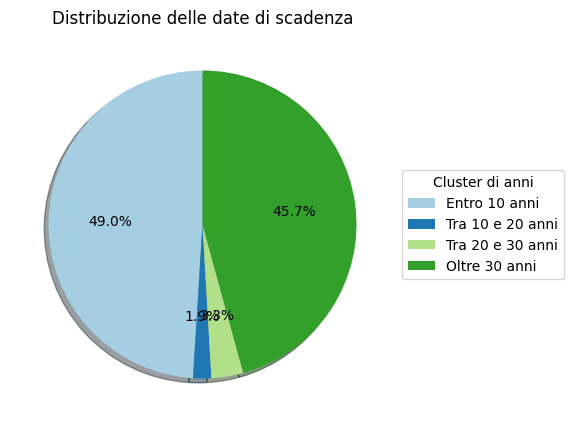


--- TOP 10 COMPANY CON SCADENZE OLTRE 30 ANNI ---
1. C.C.I.A.A. DI ROMA: 314638 record
2. AREA S.R.L.: 97311 record
3. C.C.I.A.A. DI SALERNO: 77167 record
4. Autostrade per l Italia S.p.A.: 60110 record
5. Comune di Bologna: 59026 record
6. Comune di San Giuseppe Vesuviano: 53130 record
7. C.C.I.A.A. DI FROSINONE - LATINA: 45672 record
8. ACQUEDOTTO PUGLIESE S.P.A.: 37854 record
9. C.C.I.A.A. DI TORINO: 34261 record
10. Ge.Fi.L. Spa - Gestione Fiscalita' Locale: 32143 record


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
from tqdm import tqdm
from collections import Counter

def analyze_due_dates(df):
    total = len(df)
    if total == 0:
        print("Nessun record presente nel dataset.")
        return
    
    # Debug: stampa il primo record se esiste
    if 'due_date' in df.columns and not df['due_date'].empty:
        print("Primo record:", df.iloc[0]['due_date'])
    
    # Definisci la data attuale
    today = datetime.now(timezone.utc)
    
    # Definisci i cluster di anni
    clusters = {
        "Entro 10 anni": 10,
        "Tra 10 e 20 anni": 20,
        "Tra 20 e 30 anni": 30,
        "Oltre 30 anni": float('inf')
    }
    
    # Conta i record per ciascun cluster e lista per le company "Oltre 30 anni"
    cluster_counts = {key: [] for key in clusters.keys()}
    over_30_companies = []

    # Iteriamo sul dataframe considerando sia la data che il nome dell'azienda
    # Filtriamo i record che hanno la data non nulla
    df_filtered = df.dropna(subset=['due_date'])

    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Elaborazione record", unit=" record"):
        try: 
            date_val = row['due_date']
            company = row['company_name']
            
            # Converti da microsecondi a secondi
            timestamp_seconds = date_val / 1_000_000
            
            # Converte in datetime
            date_converted = datetime.fromtimestamp(timestamp_seconds, tz=timezone.utc)
            
            # Calcolo differenza in anni
            delta_years = (date_converted - today).total_seconds() / (365 * 24 * 3600)
            
            for cluster, years in clusters.items():
                if delta_years <= years:
                    cluster_counts[cluster].append(date_converted.strftime("%d/%m/%Y"))
                    
                    # Se il cluster è "Oltre 30 anni", salviamo la company
                    if cluster == "Oltre 30 anni":
                        over_30_companies.append(company)
                    break
        except Exception:
            continue
    
    # 1. Stampa i risultati dei cluster
    print("\n--- ANALISI CLUSTER TEMPORALI ---")
    for cluster, dates in cluster_counts.items():
        count = len(dates)
        print(f"{cluster}: {count} record ({count / total * 100:.2f}%)")
        
        if cluster != "Entro 10 anni" and count > 0:
            date_counts = Counter(dates)
            for date, freq in date_counts.items():
                print(f"  - {date} {freq}")
    
    # 2. Creazione grafico a torta
    plt.figure(figsize=(8, 5))
    counts = [len(dates) for dates in cluster_counts.values()]
    plt.pie(counts, autopct='%1.1f%%', colors=plt.cm.Paired.colors, shadow=True, startangle=90)
    plt.legend(cluster_counts.keys(), title="Cluster di anni", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.title("Distribuzione delle date di scadenza")
    plt.subplots_adjust(right=0.7)
    plt.show()

    # 3. Analisi Top 10 Company (Oltre 30 anni) - AGGIUNTA
    print("\n--- TOP 10 COMPANY CON SCADENZE OLTRE 30 ANNI ---")
    if over_30_companies:
        top_companies = Counter(over_30_companies).most_common(10)
        for i, (name, count) in enumerate(top_companies, 1):
            print(f"{i}. {name}: {count} record")
    else:
        print("Nessun record trovato con scadenza superiore a 30 anni.")

# Esempio di chiamata (assumendo che 'dataframe' sia definito)
analyze_due_dates(dataframe)